In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("javagarm/fifa-19-complete-player-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.16M/2.16M [00:00<00:00, 119MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/javagarm/fifa-19-complete-player-dataset/versions/1


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
sns.set(style="whitegrid")
import matplotlib.pyplot as plt
from collections import Counter
%matplotlib inline
import os

In [7]:
df = pd.read_csv(path + '/kl.csv', index_col=0, encoding='latin-1') # or 'cp1252', 'iso-8859-1'
df

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31.0,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94.0,94,FC Barcelona,https://cdn.sofifa.org/teams/2/light/241.png,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,226.5M
1,20801,Cristiano Ronaldo,33.0,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94.0,94,Juventus,https://cdn.sofifa.org/teams/2/light/45.png,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,127.1M
2,190871,Neymar Jr,26.0,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92.0,93,Paris Saint-Germain,https://cdn.sofifa.org/teams/2/light/73.png,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,228.1M
3,193080,De Gea,27.0,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91.0,93,Manchester United,https://cdn.sofifa.org/teams/2/light/11.png,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,138.6M
4,192985,K. De Bruyne,27.0,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91.0,92,Manchester City,https://cdn.sofifa.org/teams/2/light/10.png,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,196.4M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,238813,J. Lundstram,19.0,https://cdn.sofifa.org/players/4/19/238813.png,England,https://cdn.sofifa.org/flags/14.png,47.0,65,Crewe Alexandra,https://cdn.sofifa.org/teams/2/light/121.png,...,45.0,40.0,48.0,47.0,10.0,13.0,7.0,8.0,9.0,143K
18203,243165,N. Christoffersson,19.0,https://cdn.sofifa.org/players/4/19/243165.png,Sweden,https://cdn.sofifa.org/flags/46.png,47.0,63,Trelleborgs FF,https://cdn.sofifa.org/teams/2/light/703.png,...,42.0,22.0,15.0,19.0,10.0,9.0,9.0,5.0,12.0,113K
18204,241638,B. Worman,16.0,https://cdn.sofifa.org/players/4/19/241638.png,England,https://cdn.sofifa.org/flags/14.png,47.0,67,Cambridge United,https://cdn.sofifa.org/teams/2/light/1944.png,...,41.0,32.0,13.0,11.0,6.0,5.0,10.0,6.0,13.0,165K
18205,246268,D. Walker-Rice,17.0,https://cdn.sofifa.org/players/4/19/246268.png,England,https://cdn.sofifa.org/flags/14.png,47.0,66,Tranmere Rovers,https://cdn.sofifa.org/teams/2/light/15048.png,...,46.0,20.0,25.0,27.0,14.0,6.0,14.0,8.0,9.0,143K


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18207 entries, 0 to 18206
Data columns (total 88 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  object 
 2   Age                       18206 non-null  float64
 3   Photo                     18207 non-null  object 
 4   Nationality               18207 non-null  object 
 5   Flag                      18207 non-null  object 
 6   Overall                   18206 non-null  float64
 7   Potential                 18207 non-null  int64  
 8   Club                      17966 non-null  object 
 9   Club Logo                 18207 non-null  object 
 10  Value                     18207 non-null  object 
 11  Wage                      18207 non-null  object 
 12  Special                   18207 non-null  int64  
 13  Preferred Foot            18159 non-null  object 
 14  Internation

<ipython-input-10-a4f4251e43f9>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Age,bins=10)


<Axes: xlabel='Age', ylabel='Density'>

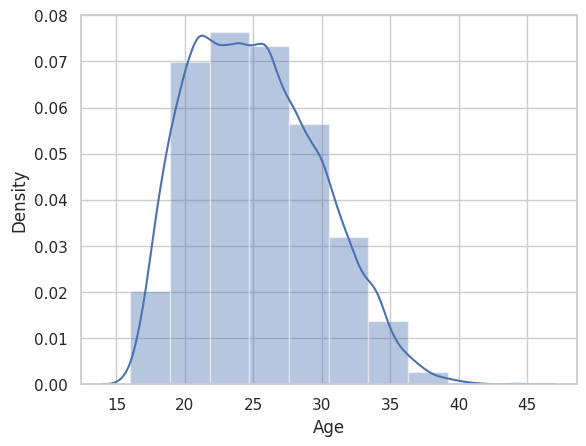

In [10]:
sns.distplot(df.Age,bins=10)

<ipython-input-11-68787547a3f6>:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.Age, shade=True)


<Axes: xlabel='Age', ylabel='Density'>

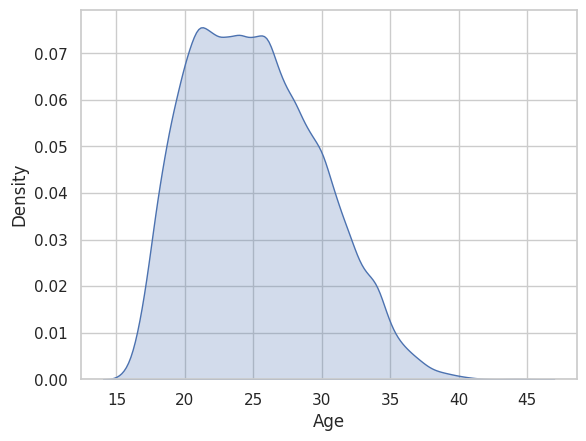

In [11]:
sns.kdeplot(df.Age, shade=True)

<ipython-input-15-4320278ca708>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Age, kde=False, rug=True, bins=10)


<Axes: xlabel='Age'>

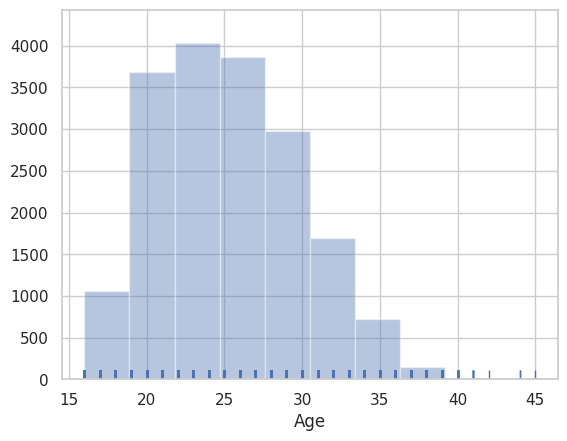

In [15]:
sns.distplot(df.Age, kde=False, rug=True, bins=10)

In [16]:
df['Preferred Foot'].value_counts()


,count
Preferred Foot,
Right,13948
Left,4211


<Axes: xlabel='Preferred Foot', ylabel='count'>

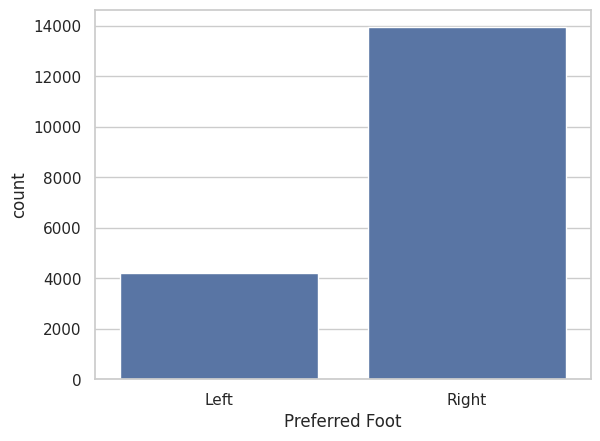

In [17]:
sns.countplot(x='Preferred Foot', data=df)

<Axes: xlabel='Preferred Foot', ylabel='count'>

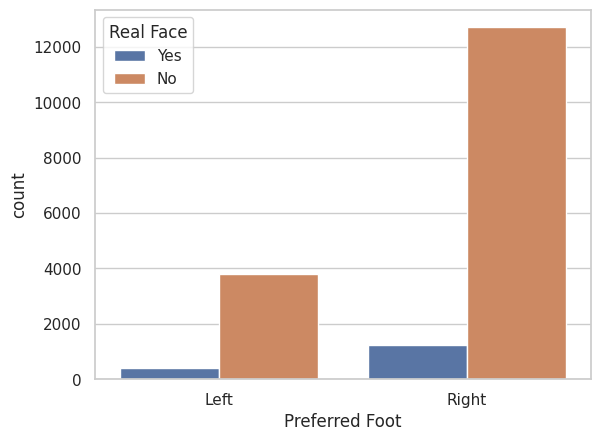

In [18]:
sns.countplot(x='Preferred Foot',hue='Real Face', data=df)

In [19]:
df['International Reputation'].value_counts()

,count
International Reputation,
1.0,16532
2.0,1261
3.0,309
4.0,51
5.0,6


<Axes: xlabel='International Reputation', ylabel='Potential'>

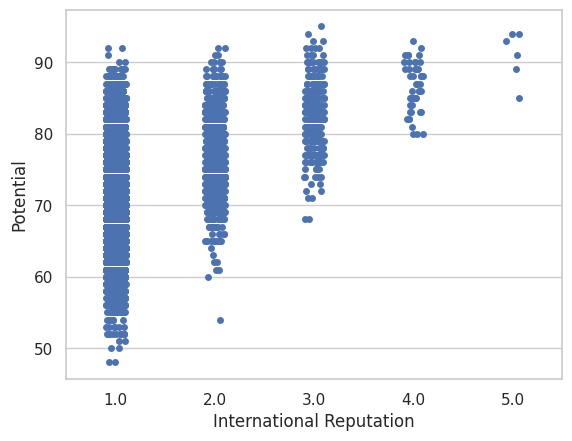

In [21]:
# prompt: stripplot

sns.stripplot(x='International Reputation', y='Potential', data=df, jitter=True)


<Axes: xlabel='International Reputation', ylabel='Potential'>

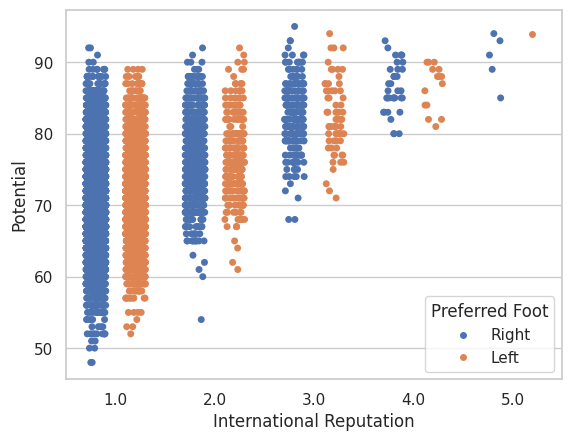

In [24]:
# prompt: stripplot

sns.stripplot(x='International Reputation', y='Potential',hue='Preferred Foot', data=df, jitter=0.2,dodge=True)


<Axes: xlabel='Potential'>

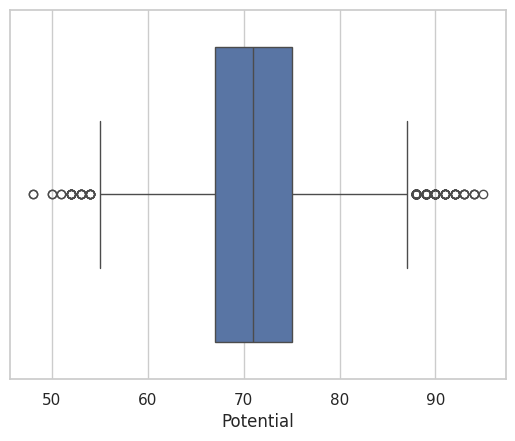

In [25]:
# prompt: potential box plot

sns.boxplot(x='Potential', data=df)


<Axes: xlabel='International Reputation', ylabel='Potential'>

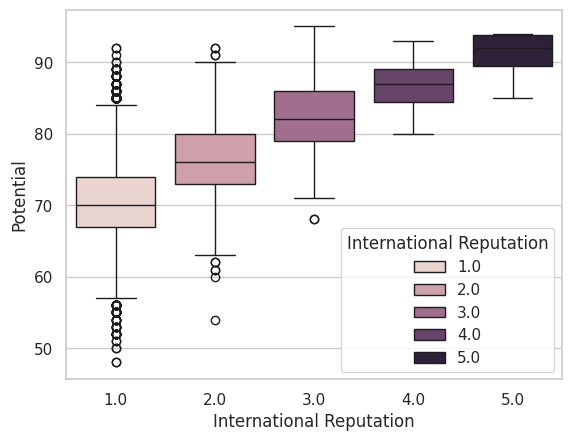

In [27]:
# prompt: potential box plot

sns.boxplot(x='International Reputation',hue='International Reputation', y='Potential', data=df)


<Axes: xlabel='International Reputation', ylabel='Potential'>

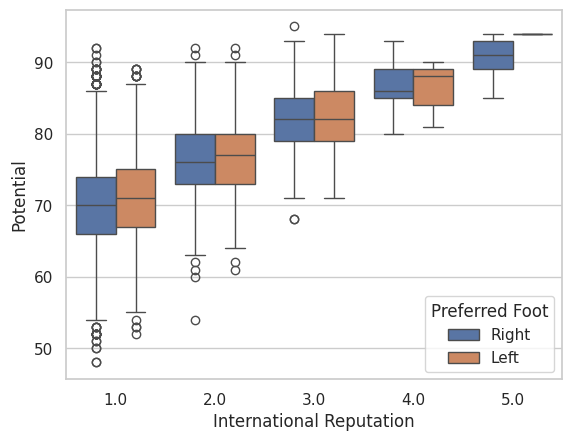

In [28]:
sns.boxplot(x='International Reputation',hue="Preferred Foot", y='Potential', data=df)


<Axes: xlabel='Potential'>

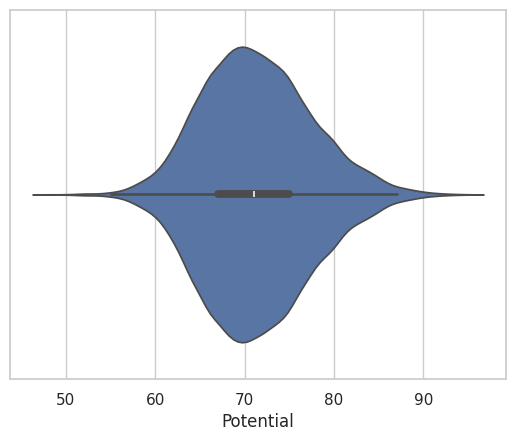

In [30]:
sns.violinplot(x=df["Potential"])

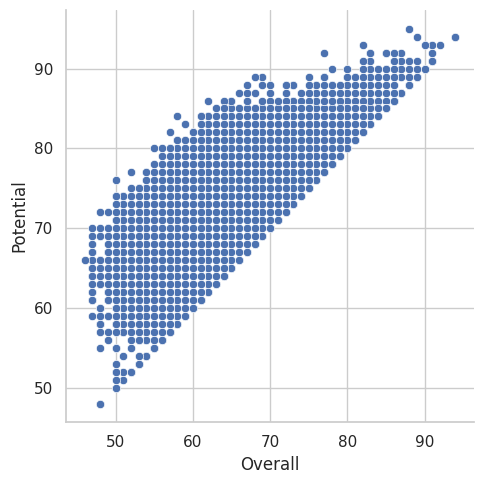

In [31]:
 sns.relplot(x="Overall", y="Potential", data=df)

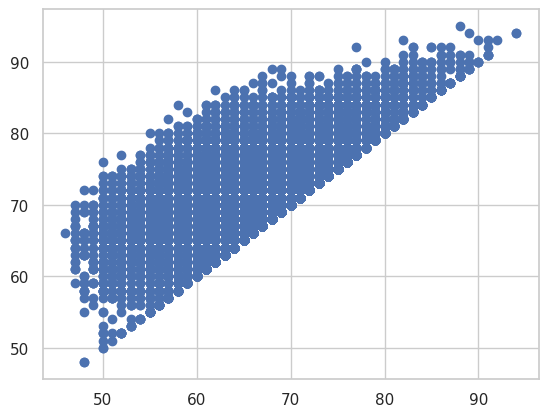

In [32]:
plt.scatter(df['Overall'], df['Potential'])

<Axes: xlabel='Stamina', ylabel='Strength'>

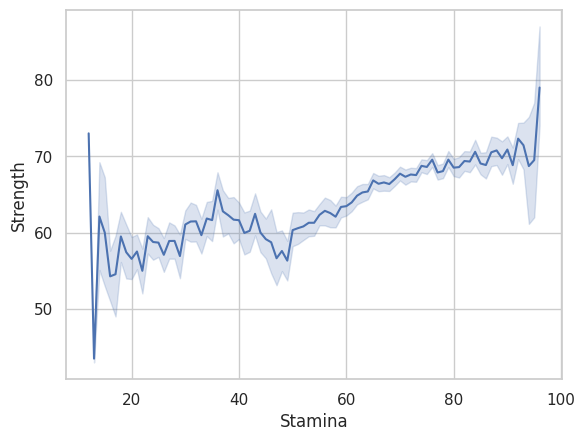

In [35]:
sns.lineplot(x="Stamina", y="Strength", data=df)


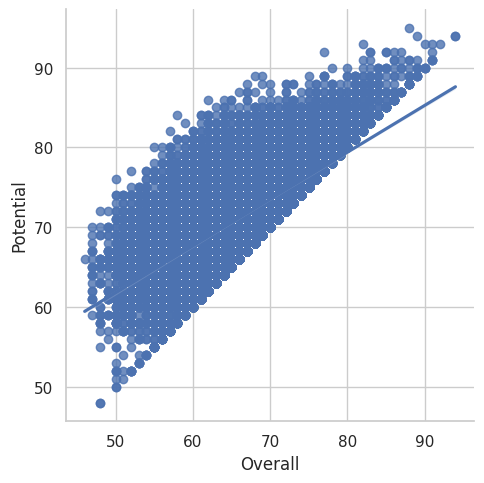

In [42]:
sns.lmplot(x='Overall', y='Potential',data=df)


<Axes: xlabel='Overall', ylabel='Potential'>

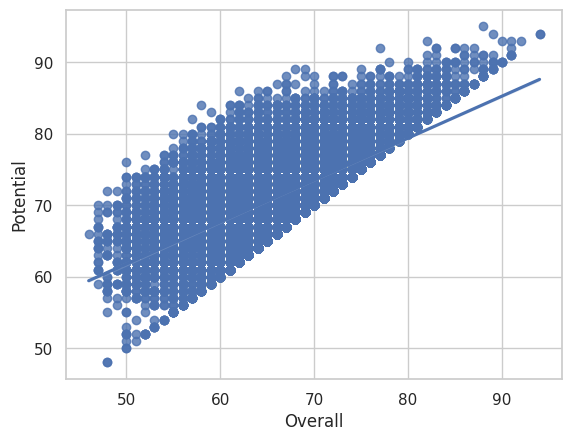

In [41]:
sns.regplot(x='Overall', y='Potential',data=df)


In [43]:
df_new =df[['Age','Potential','Strength','Stamina','Preferred Foot']]


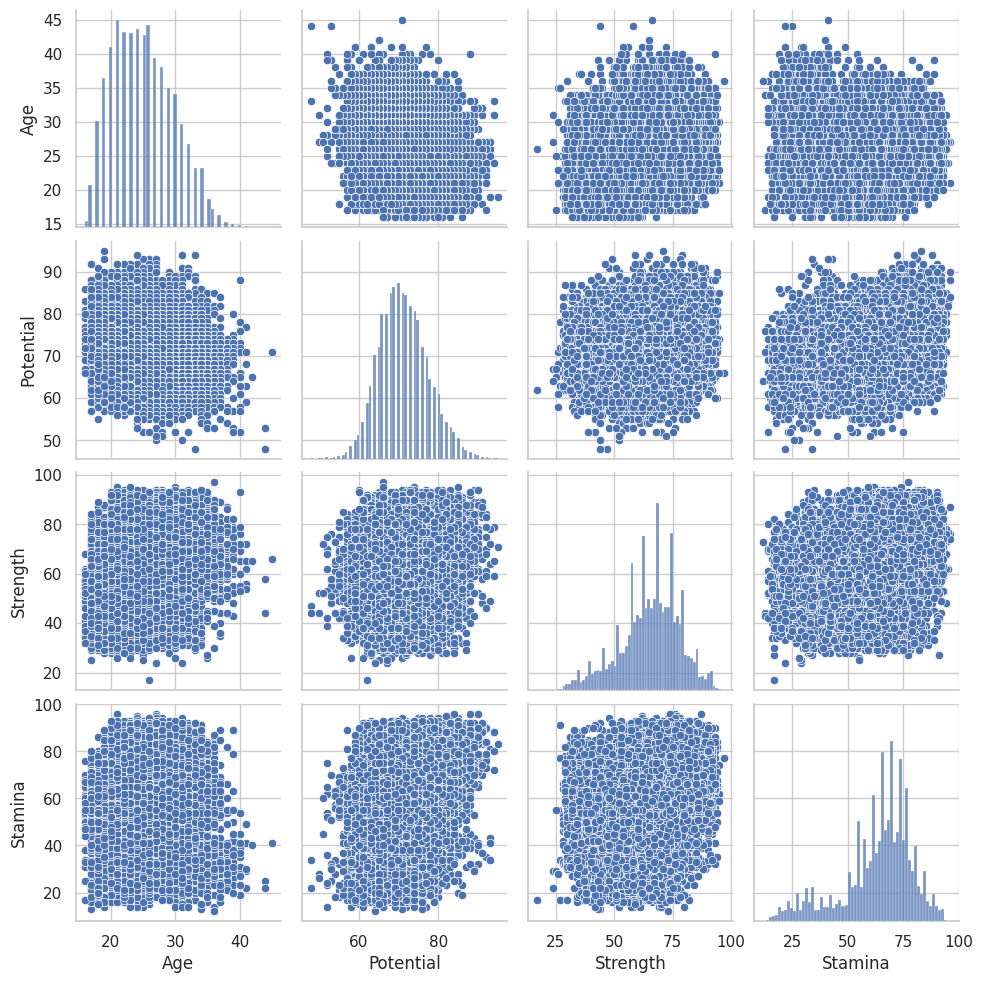

In [45]:
sns.pairplot(df_new)

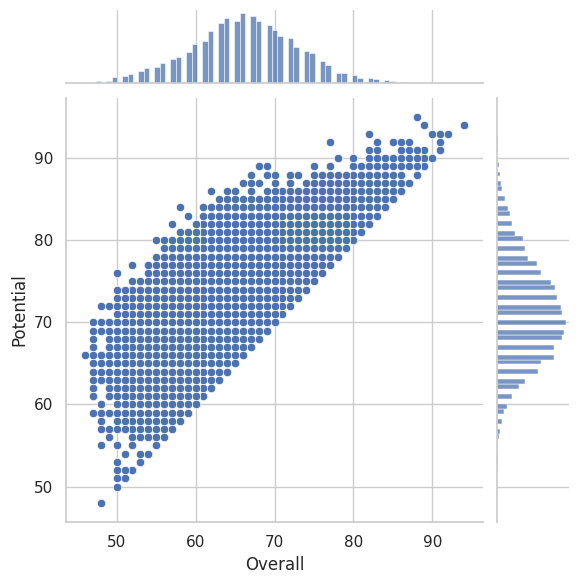

In [47]:
# prompt: joint grid

sns.jointplot(x='Overall', y='Potential', data=df)


In [48]:
# prompt: sinplot

import matplotlib.pyplot as plt
import numpy as np

def sinplot(flip=1):
    x = np.linspace(0, 14, 100)
    for i in range(1, 7):
        plt.plot(x, np.sin(x + i * .5) * (7 - i) * flip)


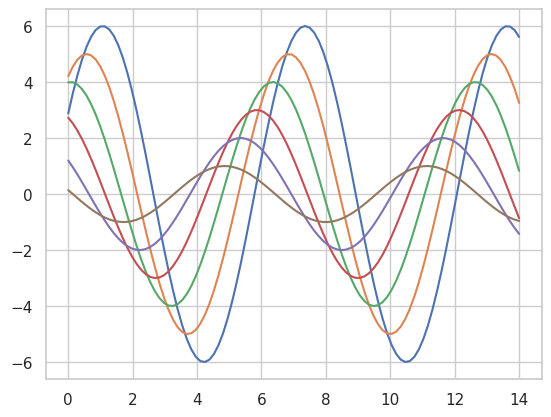

In [49]:
sinplot()
